# Module 1 Assignment — Question 2 — Instrument & Compare Runs (MNIST + MLP)
### AI Operations (AIOps) — MLflow Deep Dive | adapted from Hands-on Exercise 1

**Referenced in:** *MLflow Deep Dive Slide Deck*, Section 1 (Experiment Tracking Deep Dive)

**Objective:** take the Exercise 1 starter script, swap the dataset from **IRIS to MNIST** and the
and use `mlflow.search_runs()` to find the best run programmatically.

**Steps (from the slide deck, with the assignment's substitutions):**
1. Take the provided starter script (`fetch_openml("mnist_784")` → train a classifier — no MLflow calls yet).
2. Add `mlflow.set_experiment()` and wrap training in `with mlflow.start_run():`.
3. Log at least 3 hyperparameters and 2 metrics manually.
4. Re-run the script 6 times varying **two** hyperparameters (`learning_rate_init` × `batch_size`).
6. Open the MLflow UI, select all 6 sweep runs, and use **Compare** to find the best one.

**Deliverable:** a screenshot of the 6-run comparison view, plus the `run_id` of the best run found
via `mlflow.search_runs()`.

> **Prerequisite:** a local MLflow Tracking Server must already be running:
> ```bash
> mlflow server --backend-store-uri sqlite:///mlflow.db \
>     --default-artifact-root ./mlruns --host 0.0.0.0 --port 5000 --allowed-hosts "*" --cors-allowed-origins "http://localhost:5000, http://127.0.0.1:5000"
> ```
> Run that command in a separate terminal *before* executing the cells below, then leave it running.

## Step 0 — Setup
Install dependencies (skip if already installed) and import libraries.

In [1]:
# !pip install mlflow scikit-learn pandas --quiet

import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mnist-mlp")
print("Tracking URI:", mlflow.get_tracking_uri())

2026/08/30 12:01:13 INFO mlflow.tracking.fluent: Experiment with name 'mnist-mlp' does not exist. Creating a new experiment.


Tracking URI: http://localhost:5000


## Step 1 — The starter script (un-instrumented)
This is the "before" version — plain scikit-learn, no tracking at all. Run it once just to confirm it works.

In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=True)
X = X / 255.0
y = y.astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def train_and_evaluate(hidden_layer_sizes=(64,), learning_rate_init=0.001, batch_size=128):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        max_iter=20,
        early_stopping=True,
        random_state=42,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    return model, acc, f1

# Sanity check — no MLflow involved yet
_, acc, f1 = train_and_evaluate()
print(f"accuracy={acc:.4f}  f1_macro={f1:.4f}")

accuracy=0.9699  f1_macro=0.9697


/home/sujal/miniconda3/envs/aiops/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


## Step 2 & 3 — Instrument it: manual logging
Wrap training in `with mlflow.start_run():` and log parameters, metrics, and a tag.

In [3]:
def train_and_log(hidden_layer_sizes=(64,), learning_rate_init=0.001, batch_size=128, run_name=None):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("hidden_layer_sizes", hidden_layer_sizes)
        mlflow.log_param("learning_rate_init", learning_rate_init)
        mlflow.log_param("batch_size", batch_size)

        model, acc, f1 = train_and_evaluate(hidden_layer_sizes, learning_rate_init, batch_size)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1)

        for epoch, (train_loss, val_acc) in enumerate(zip(model.loss_curve_, model.validation_scores_)):
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_accuracy", val_acc, step=epoch)

        mlflow.set_tag("team", "data-science")
        mlflow.sklearn.log_model(model, name="model", serialization_format="cloudpickle")

        run_id = mlflow.active_run().info.run_id
        print(f"Logged run {run_id}  |  acc={acc:.4f}  f1={f1:.4f}")
        return run_id

## Step 4 — Sweep: 6 runs varying `learning_rate_init` and `batch_size`
Re-run with different values and log each as its own MLflow run.

In [4]:
sweep_run_ids = []
for lr in [0.01, 0.001, 0.0002]:
    for bs in [24, 208]:
        rid = train_and_log(hidden_layer_sizes=(64,), learning_rate_init=lr, batch_size=bs,
                             run_name=f"mlp-lr{lr}-bs{bs}")
        sweep_run_ids.append(rid)

print("Sweep run IDs:", sweep_run_ids)

2026/08/30 12:03:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run dda126a31bdf4409b125e5301b1811f4  |  acc=0.9565  f1=0.9561
🏃 View run mlp-lr0.01-bs24 at: http://localhost:5000/#/experiments/4/runs/dda126a31bdf4409b125e5301b1811f4
🧪 View experiment at: http://localhost:5000/#/experiments/4


2026/08/30 12:04:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run 3d76d9f8640f4ccbb234452cae291e81  |  acc=0.9713  f1=0.9711
🏃 View run mlp-lr0.01-bs208 at: http://localhost:5000/#/experiments/4/runs/3d76d9f8640f4ccbb234452cae291e81
🧪 View experiment at: http://localhost:5000/#/experiments/4


/home/sujal/miniconda3/envs/aiops/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
2026/08/30 12:05:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Logged run 62a717acb0c241d7b5807ac5ce2206e0  |  acc=0.9693  f1=0.9691
🏃 View run mlp-lr0.001-bs208 at: http://localhost:5000/#/experiments/4/runs/62a717acb0c241d7b5807ac5ce2206e0
🧪 View experiment at: http://localhost:5000/#/experiments/4


/home/sujal/miniconda3/envs/aiops/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
2026/08/30 12:06:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run 3792a1ac790d4128a06c031d2f18b125  |  acc=0.9682  f1=0.9680
🏃 View run mlp-lr0.0002-bs24 at: http://localhost:5000/#/experiments/4/runs/3792a1ac790d4128a06c031d2f18b125
🧪 View experiment at: http://localhost:5000/#/experiments/4


/home/sujal/miniconda3/envs/aiops/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
2026/08/30 12:07:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run 312e6e260e2d4ceb96cc4a10ef62ce5c  |  acc=0.9539  f1=0.9536
🏃 View run mlp-lr0.0002-bs208 at: http://localhost:5000/#/experiments/4/runs/312e6e260e2d4ceb96cc4a10ef62ce5c
🧪 View experiment at: http://localhost:5000/#/experiments/4
Sweep run IDs: ['dda126a31bdf4409b125e5301b1811f4', '3d76d9f8640f4ccbb234452cae291e81', '8fb095b951d846f081ec6adae779232b', '62a717acb0c241d7b5807ac5ce2206e0', '3792a1ac790d4128a06c031d2f18b125', '312e6e260e2d4ceb96cc4a10ef62ce5c']


## Step 5 — Find the best run with `mlflow.search_runs()`
No need to open the UI to find the winner — query it directly.

In [5]:
runs_df = mlflow.search_runs(
    experiment_names=["mnist-mlp"],
    order_by=["metrics.accuracy DESC"],
)

display_cols = [c for c in runs_df.columns if c in (
    "run_id", "tags.mlflow.runName", "params.learning_rate_init", "params.batch_size", "metrics.accuracy", "metrics.f1_macro"
)]
print(runs_df[display_cols].head(10).to_string(index=False))

best_run = runs_df.iloc[0]
print(f"\nBest run: {best_run['run_id']}  (accuracy={best_run['metrics.accuracy']:.4f})")

                          run_id  metrics.f1_macro  metrics.accuracy params.learning_rate_init params.batch_size tags.mlflow.runName
8fb095b951d846f081ec6adae779232b          0.972522          0.972786                     0.001                24    mlp-lr0.001-bs24
3d76d9f8640f4ccbb234452cae291e81          0.971103          0.971286                      0.01               208    mlp-lr0.01-bs208
62a717acb0c241d7b5807ac5ce2206e0          0.969109          0.969286                     0.001               208   mlp-lr0.001-bs208
3792a1ac790d4128a06c031d2f18b125          0.967957          0.968214                    0.0002                24   mlp-lr0.0002-bs24
dda126a31bdf4409b125e5301b1811f4          0.956103          0.956500                      0.01                24     mlp-lr0.01-bs24
312e6e260e2d4ceb96cc4a10ef62ce5c          0.953590          0.953929                    0.0002               208  mlp-lr0.0002-bs208

Best run: 8fb095b951d846f081ec6adae779232b  (accuracy=0.9728)


## Step 6 — Plot the per-epoch curves and log them to MLflow

`train_and_log` already logged `train_loss` and `val_accuracy` with `step=epoch`, so MLflow holds the
full 20-point history for every run. Here we read those histories back with `MlflowClient.get_metric_history`,
draw one comparison figure, and log it straight into MLflow with `mlflow.log_figure` (no local file).

mlp-lr0.0002-bs208     final train_loss=0.1340  final val_acc=0.9518  best val_acc=0.9518  overfit_gap=+0.0000
mlp-lr0.0002-bs24      final train_loss=0.0500  final val_acc=0.9680  best val_acc=0.9693  overfit_gap=+0.0012
mlp-lr0.001-bs208      final train_loss=0.0333  final val_acc=0.9716  best val_acc=0.9716  overfit_gap=+0.0000
mlp-lr0.001-bs24       final train_loss=0.0147  final val_acc=0.9721  best val_acc=0.9752  overfit_gap=+0.0030
mlp-lr0.01-bs208       final train_loss=0.0307  final val_acc=0.9698  best val_acc=0.9720  overfit_gap=+0.0021
mlp-lr0.01-bs24        final train_loss=0.1506  final val_acc=0.9541  best val_acc=0.9586  overfit_gap=+0.0045


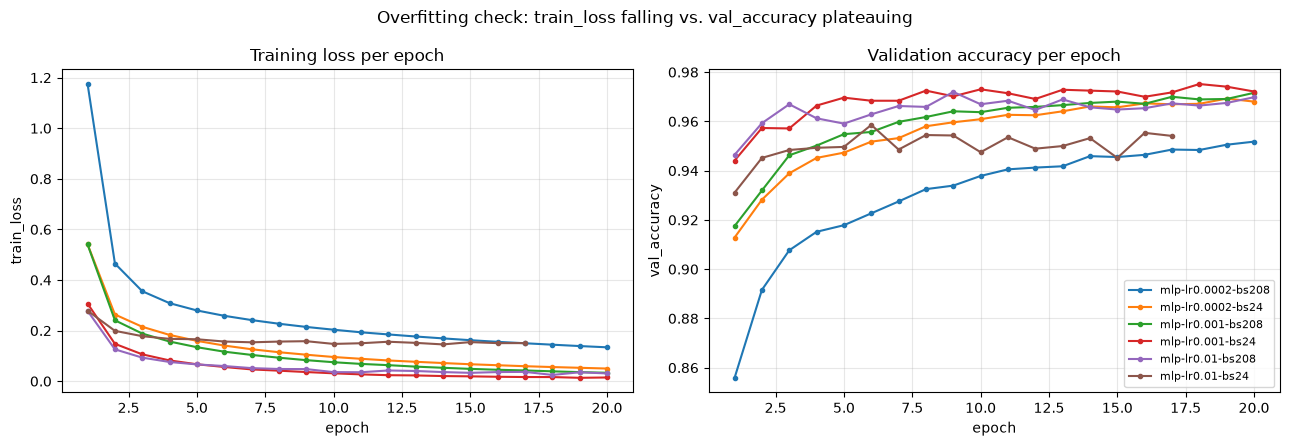

In [6]:
import matplotlib.pyplot as plt
from mlflow import MlflowClient

client = MlflowClient()
exp = client.get_experiment_by_name("mnist-mlp")
runs = [r for r in client.search_runs([exp.experiment_id]) if r.info.status == "FINISHED"]
runs = sorted(runs, key=lambda r: r.data.tags.get("mlflow.runName", ""))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for r in runs:
    name = r.data.tags.get("mlflow.runName", r.info.run_id[:8])
    loss = [m.value for m in client.get_metric_history(r.info.run_id, "train_loss")]
    vacc = [m.value for m in client.get_metric_history(r.info.run_id, "val_accuracy")]
    ax1.plot(range(1, len(loss) + 1), loss, marker="o", ms=3, label=name)
    ax2.plot(range(1, len(vacc) + 1), vacc, marker="o", ms=3, label=name)
    print(f"{name:22s} final train_loss={loss[-1]:.4f}  final val_acc={vacc[-1]:.4f}  "
          f"best val_acc={max(vacc):.4f}  overfit_gap={max(vacc) - vacc[-1]:+.4f}")

ax1.set_xlabel("epoch"); ax1.set_ylabel("train_loss"); ax1.set_title("Training loss per epoch")
ax2.set_xlabel("epoch"); ax2.set_ylabel("val_accuracy"); ax2.set_title("Validation accuracy per epoch")
ax1.grid(alpha=.3); ax2.grid(alpha=.3)
ax2.legend(fontsize=8, loc="lower right")
fig.suptitle("Overfitting check: train_loss falling vs. val_accuracy plateauing")
fig.tight_layout()